## Training script

In [29]:
# Jupyter notebook auto reload
%load_ext autoreload
%autoreload 2

import os
import json
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from char_tokenizer import TinyArithmeticCharTokenizer
from tiny_transformer import TinyArithmeticTransformer
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

CHECKPOINT_DIR = "/teamspace/studios/this_studio/small-transformer-model-arithmetic-math/checkpoints"
DATA_DIR = "/teamspace/studios/this_studio/small-transformer-model-arithmetic-math/data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

batch_size = 64
base_lr = 1e-4 # setting small learning rate was super helpful!!!
warmup_epochs = 10

# testing larger model ~85mm params
d_model = 768
max_seq_len = 128
num_heads = 12
num_layers = 12

# Smaller model ~25mm params, got stuck with 1_int_plus_1_to_5_size_100k, wasn't able to learn...
# d_model = 512
# max_seq_len = 128
# num_heads = 8
# num_layers = 8

train_percent = 0.80
val_percent   = 0.10
test_percent  = 0.10

rand_seed = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training on device: cuda


### Loading dataset, adding "=" between input and output, tokenization, and adding padding

In [30]:
tokenizer = TinyArithmeticCharTokenizer()

dataset_name = '2_mixed_plus_1_to_2_size_200k'

dataset_path = os.path.join(DATA_DIR, f"{dataset_name}.json")

with open(dataset_path, "r") as f:
    raw_data = json.load(f)

tokenized_sequences = []
for expression, result in raw_data:
    # debugging: trying out reverse string for the output
    reversed_result = str(result)[::-1]
    
    full_str = f"{expression}={reversed_result}"
    eos_token_id = tokenizer.char_to_int["<eos>"]
    encoded_ids = tokenizer.encode(full_str)
    encoded_ids.append(eos_token_id)
    tokenized_sequences.append(encoded_ids)

pad_id = tokenizer.char_to_int["<pad>"]

padded_sequences = []
for seq in tokenized_sequences:
    if len(seq) < max_seq_len:
        seq = seq + [pad_id] * (max_seq_len - len(seq))
    else:
        seq = seq[:max_seq_len]
    padded_sequences.append(seq)

dataset_tensor = torch.tensor(padded_sequences, dtype=torch.long)

print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(dataset_tensor[:1])

Dataset securely loaded in-memory. Matrix shape: torch.Size([200000, 128])
The <eos> token id is: 19
tensor([[11,  1,  8, 16, 10, 16,  8,  1, 15,  7,  8, 14,  8,  7, 15,  3,  6, 19,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17]])


### Preparing training, validation, testing datasets.

In [31]:
total_rows = dataset_tensor.size(0)

train_size = int(train_percent * total_rows)
val_size   = int(val_percent * total_rows)
test_size  = total_rows - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    dataset_tensor, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(rand_seed)
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train Loader: {len(train_loader)} batches (Total: {len(train_subset)} shuffled rows)")
print(f"Val Loader:   {len(val_loader)} batches (Total: {len(val_subset)} shuffled rows)")
print(f"Test Loader:  {len(test_loader)} batches (Total: {len(test_subset)} shuffled rows)")

Train Loader: 2500 batches (Total: 160000 shuffled rows)
Val Loader:   313 batches (Total: 20000 shuffled rows)
Test Loader:  313 batches (Total: 20000 shuffled rows)


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

vocab_size   = tokenizer.vocab_size  
eq_token_id  = tokenizer.char_to_int["="]     
pad_token_id = tokenizer.char_to_int["<pad>"]

model = TinyArithmeticTransformer(vocab_size=vocab_size, d_model=d_model, max_seq_len=max_seq_len, num_layers=num_layers, num_heads=num_heads)
model = model.to(device)
    
optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.1)
loss_fct  = nn.CrossEntropyLoss(reduction='none')

def warmup_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return float(current_epoch) / float(max(1, warmup_epochs))
    return 1.0  # Multiplier stays at 1.0 (flat 3e-4) for the remaining epochs

scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)

train_loss_history = []
val_loss_history = []

Training on device: cuda


In [112]:
model

TinyArithmeticTransformer(
  (token_embedding_layer): Embedding(20, 768)
  (positional_encoding): PositionalEncoding()
  (layers): ModuleList(
    (0-11): 12 x TransformerBlock(
      (pre_attention_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (multi_head_attention): MultiHeadAttention(
        (q_linear): Linear(in_features=768, out_features=768, bias=True)
        (k_linear): Linear(in_features=768, out_features=768, bias=True)
        (v_linear): Linear(in_features=768, out_features=768, bias=True)
        (out_linear): Linear(in_features=768, out_features=768, bias=True)
      )
      (pre_ffn_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
  )
  (final_layernorm): LayerNorm((768,), eps=1e-05, elementwise_aff

#### Helper function to compute the loss mask. Later when calculating loss, since our prefix inputs is full attention and sees every token, we dont want to calculate loss for prefix tokens. We also don't want to calculate loss for <pad> after our <eos>. This loss mask will produce a [0, 1] float dtype mask so we zero out the loss from tokens we dont care about, leaving only the loss updates for the output tokens and <eos>.

In [33]:
def compute_loss_mask(targets: torch.Tensor, eq_token_id: int, pad_token_id: int) -> torch.Tensor:
    batch_size, seq_len = targets.shape
    
    eq_indices = (targets == eq_token_id).int().argmax(dim=-1).view(batch_size, 1)
    pos_grid = torch.arange(seq_len, device=targets.device).view(1, seq_len)
    
    is_after_eq = (pos_grid > eq_indices)
    is_not_pad  = (targets != pad_token_id)
    
    loss_mask = (is_after_eq & is_not_pad).float().view(-1)
    return loss_mask


def plot_live_loss(train_history, val_history, current_epoch, total_target_epochs):
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    epochs_range = list(range(1, len(train_history) + 1))
    
    ax.plot(epochs_range, train_history, label='Training Loss', color='royalblue', linewidth=2, marker='.', markersize=4)
    ax.plot(epochs_range, val_history, label='Validation Loss', color='darkorange', linewidth=2, marker='.', markersize=4)
    
    ax.set_title('Live Training and Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
    
    num_epochs = len(epochs_range)
    if num_epochs <= 20:
        step = 1       
    elif num_epochs <= 50:
        step = 5      
    elif num_epochs <= 200:
        step = 10      
    else:
        step = 25      
        
   
    custom_ticks = [1] + list(range(step, num_epochs + 1, step))
    if num_epochs not in custom_ticks:
        custom_ticks.append(num_epochs)
        
    ax.set_xticks(custom_ticks)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    
    print(f"Latest Stats -> Epoch {current_epoch:02d}/{total_target_epochs:02d} | "
          f"Train Loss: {train_history[-1]:.4f} | Val Loss: {val_history[-1]:.4f}")


def save_checkpoint(checkpoint_name, model, optimizer, train_history, val_history):
    if not os.path.exists(CHECKPOINT_DIR):
        os.makedirs(CHECKPOINT_DIR)
        print(f"Created checkpoint directory at: {CHECKPOINT_DIR}")
        
    if not checkpoint_name.endswith(".pt"):
        checkpoint_name += ".pt"
        
    checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)
    
    checkpoint_state = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss_history': train_history,
        'val_loss_history': val_history,
        'epochs_completed': len(train_history)
    }
    
    torch.save(checkpoint_state, checkpoint_path)
    print(f"Checkpoint manually saved as: {checkpoint_path}")


def load_checkpoint(checkpoint_name, model, optimizer=None):
    global train_loss_history, val_loss_history
    
    if not checkpoint_name.endswith(".pt"):
        checkpoint_name += ".pt"
        
    checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint file found at {checkpoint_path}")
        
    print(f"📂 Loading checkpoint: {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    train_loss_history = checkpoint['train_loss_history']
    val_loss_history = checkpoint['val_loss_history']
    
    print(f"Successfully restored state from {checkpoint_name} (Epochs completed: {checkpoint['epochs_completed']})")

In [34]:
# Loading checkpoint to continue training...

load_checkpoint(checkpoint_name='big_1_int_plus_1_to_5_size_100k_epoch_30.pt', model=model, optimizer=optimizer)

📂 Loading checkpoint: /teamspace/studios/this_studio/small-transformer-model-arithmetic-math/checkpoints/big_1_int_plus_1_to_5_size_100k_epoch_30.pt...
Successfully restored state from big_1_int_plus_1_to_5_size_100k_epoch_30.pt (Epochs completed: 31)


In [143]:
# Directly update the learning rate in the existing optimizer instance

# new_lr = 1e-3 # set a very HIGH lr for when I get stuck
# new_lr = 1e-4 # set a very low lr for when I get stuck
# new_lr = 3e-4 # this is base LR

# for param_group in optimizer.param_groups:
#     param_group['lr'] = new_lr

# print(f"Successfully adjusted learning rate to: {optimizer.param_groups[0]['lr']}")

In [35]:
def train_model(num_epochs_to_add: int):
    start_epoch = len(train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    scaler = torch.amp.GradScaler('cuda') # Automatic Mixed Precision
    
    for epoch in range(start_epoch, target_epoch):
        model.train()
        total_train_loss = 0.0
        
        for batch_sequences in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            batch_sequences = batch_sequences.to(device)
            
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()

            with torch.amp.autocast('cuda', dtype=torch.float16):
                attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
                
                optimizer.zero_grad()
                logits = model(inputs, mask=attn_mask)
                
                raw_loss          = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss_mask         = compute_loss_mask(targets, eq_token_id, pad_token_id)
                num_active_tokens = loss_mask.sum()
                
                loss = (raw_loss * loss_mask).sum() / max(num_active_tokens.item(), 1.0)
            
            scaler.scale(loss).backward()
            
            scaler.step(optimizer)
            
            scaler.update()
            
            total_train_loss += loss.item()

        scheduler.step() # schedule learning rate warmup
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_sequences in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()
                
                attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
                logits    = model(inputs, mask=attn_mask)
                
                raw_loss  = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss_mask = compute_loss_mask(targets, eq_token_id, pad_token_id)
                
                val_loss = (raw_loss * loss_mask).sum() / max(loss_mask.sum().item(), 1.0)
                total_val_loss += val_loss.item()
                
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss   = total_val_loss / len(val_loader)
        
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        # plotting losses
        plot_live_loss(
            train_history=train_loss_history, 
            val_history=val_loss_history, 
            current_epoch=epoch + 1, 
            total_target_epochs=target_epoch
        )

        if epoch % 10 == 0:
            save_checkpoint(
                checkpoint_name=f"big_{dataset_name}_epoch_{epoch}",
                model=model, 
                optimizer=optimizer, 
                train_history=train_loss_history, 
                val_history=val_loss_history
            )

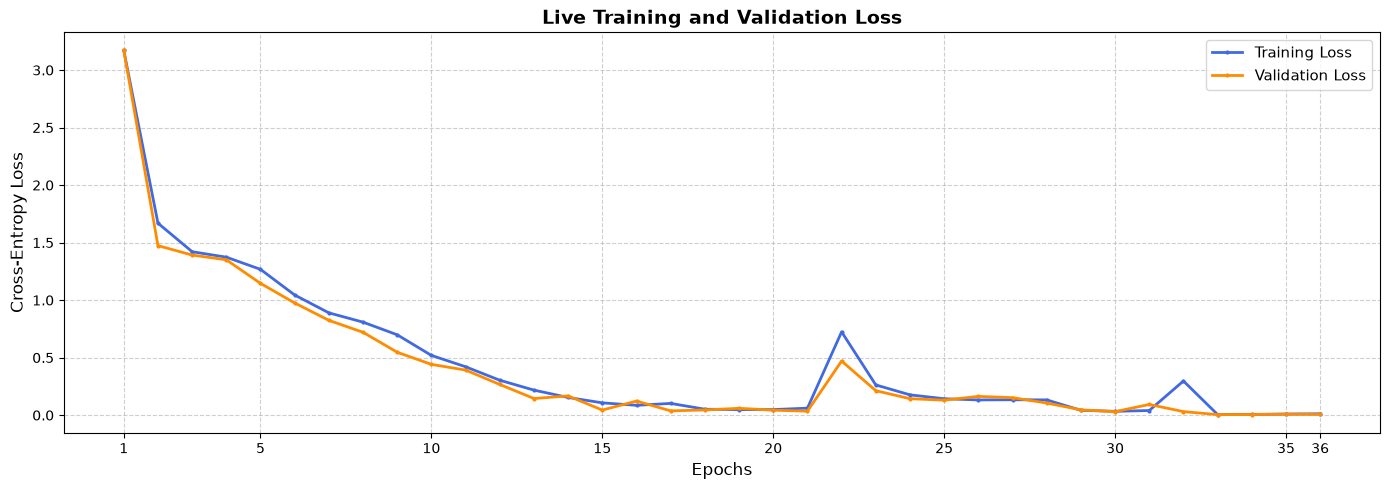

Latest Stats -> Epoch 36/36 | Train Loss: 0.0121 | Val Loss: 0.0060


In [36]:
train_model(num_epochs_to_add=5)

In [37]:
def ask_transformer(expression: str, max_gen_tokens: int = 15):
    model.eval()
    
    if not expression.endswith("="):
        expression += "="
        
    try:
        input_ids = [tokenizer.char_to_int[char] for char in expression]
    except KeyError as e:
        print(f"Error: Character {e} is not in your tokenizer's vocabulary!")
        return
        
    input_tensor = torch.tensor([input_ids], device=device)
    
    generated_tokens = []
    
    with torch.no_grad():
        for _ in range(max_gen_tokens):
            attn_mask = model.compute_prefix_lm_mask(input_tensor, eq_token_id)
            
            logits = model(input_tensor, mask=attn_mask)
            
            next_token_logits = logits[0, -1, :]
            next_token = next_token_logits.argmax().item()
            
            if next_token == tokenizer.char_to_int.get("<eos>") or next_token == pad_token_id:
                break
                
            generated_tokens.append(next_token)
            
            next_tensor = torch.tensor([[next_token]], device=device)
            input_tensor = torch.cat([input_tensor, next_tensor], dim=1)
            
    predicted_answer = "".join([tokenizer.int_to_char[t] for t in generated_tokens])[::-1]
    
    print(f"Prompt: {expression}")
    print(f"Model Output: {predicted_answer}\n")

In [38]:
ask_transformer("19 + 10")
ask_transformer("17 + 14")

ask_transformer("19 + 10 + 1")
ask_transformer("17 + 10 + 3")

ask_transformer("19.2 + 6.8")
ask_transformer("17 + 10.5")
ask_transformer("5.5 + 1.8 + 0.2")
ask_transformer("16 + 68 + 20.1")

Prompt: 19 + 10=
Model Output: 29

Prompt: 17 + 14=
Model Output: 31

Prompt: 19 + 10 + 1=
Model Output: 30

Prompt: 17 + 10 + 3=
Model Output: 30

Prompt: 19.2 + 6.8=
Model Output: 26.0

Prompt: 17 + 10.5=
Model Output: 27.5

Prompt: 5.5 + 1.8 + 0.2=
Model Output: 7.5

Prompt: 16 + 68 + 20.1=
Model Output: 104.1



In [39]:
# Saving the checkpoint 

save_checkpoint(
    checkpoint_name="success_2_mixed_plus_1_to_2_size_200k_epoch_36",
    model=model, 
    optimizer=optimizer, 
    train_history=train_loss_history, 
    val_history=val_loss_history
)

Checkpoint manually saved as: /teamspace/studios/this_studio/small-transformer-model-arithmetic-math/checkpoints/success_2_mixed_plus_1_to_2_size_200k_epoch_36.pt
